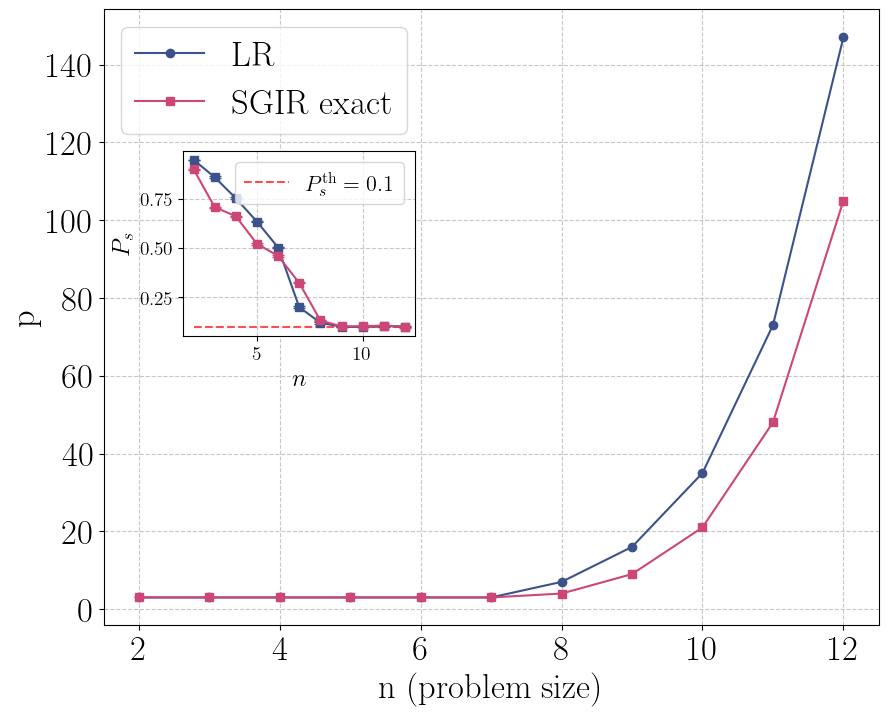

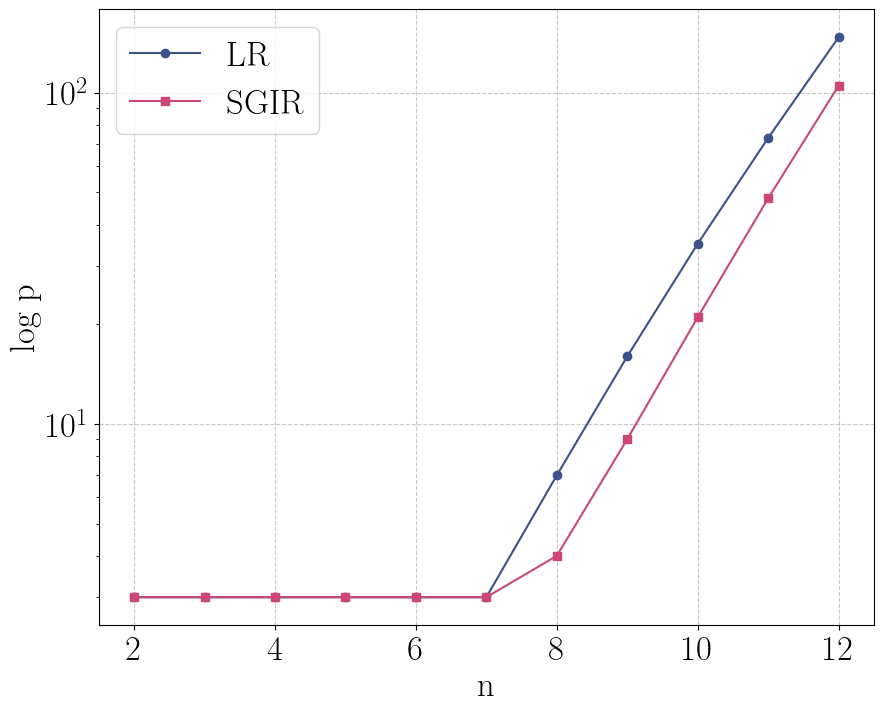

In [ ]:
# -*- coding: utf-8 -*-
"""

Plot the p with n relationship for each method when solving Grover's problem

"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({'font.size': 25})

Ps_thresh = 0.1

df_lr = pd.read_csv("results/p_with_n_LR-QAOA_3_b[-1.5, 0.5]_g[-1, 1]_d11_vRand.csv")
df_sgir = pd.read_csv("results/p_with_n_SGIR-QAOA-0k-sym_3_b[-1.5, 0.5]_g[-1, 1]_d11_vRand.csv")

df_lr = df_lr[9:]
df_sgir = df_sgir[:11]

ffig, ax = plt.subplots(figsize=(10, 8))

# --- Main plot (leave default sizes) ---
ax.plot(df_lr["n"], df_lr["p"],
        marker="o",
        color=cm.viridis(0.25),
        label="LR")

ax.plot(df_sgir["n"], df_sgir["p"],
        marker="s",
        color=cm.plasma(0.5),
        label="SGIR exact")

ax.set_xlabel("n (problem size)")
ax.set_ylabel("p")
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

# --- Inset in middle-left ---
axins = inset_axes(
    ax,
    width="30%",
    height="30%",
    bbox_to_anchor=(0.08, 0.12, 1, 1),
    bbox_transform=ax.transAxes,
    loc="center left"
)

# LR inset
axins.errorbar(
    df_lr["n"],
    df_lr["Ps_mean"],
    yerr=df_lr["Ps_std"],
    marker="s",
    linestyle="-",
    color=cm.viridis(0.25),
    capsize=4,
)

# SGIR inset
axins.errorbar(
    df_sgir["n"],
    df_sgir["Ps_mean"],
    yerr=df_sgir["Ps_std"],
    marker="s",
    linestyle="-",
    color=cm.plasma(0.5),
    capsize=4,
)

# Threshold
axins.hlines(
    Ps_thresh,
    xmin=df_sgir["n"].iloc[0],
    xmax=df_sgir["n"].iloc[-1],
    linestyles="--",
    color="red",
    alpha=0.7,
    label=rf"$P_s^{{\mathrm{{th}}}}={Ps_thresh}$"
)

# axins = fig.add_axes([4, 0.40, 0.35, 0.35])

# --- Only make inset labels bigger ---
axins.set_xlabel(r"$n$", fontsize=18)
axins.set_ylabel(r"$P_s$", fontsize=18)
axins.tick_params(axis='both', labelsize=14)
axins.legend(fontsize=16, frameon=True)

axins.grid(True, linestyle='--', alpha=0.7)


plt.savefig("plots/p_with_n_and_inset.pdf")
plt.show()






plt.figure(figsize=(10, 8))
plt.plot(df_lr["n"], df_lr["p"], marker="o", color=cm.viridis(0.25), label="LR")
plt.plot(df_sgir["n"], df_sgir["p"], marker="s",color=cm.plasma(0.5), label="SGIR")

plt.xlabel("n")
plt.ylabel("log p")
plt.yscale('log')
plt.legend()
# plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig(f"plots/logp_with_n_thrs{Ps_thresh}.pdf")
plt.show()
